## MARBL diagnostics, compare timeseries of global metrics between 2 cases


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import utils
import pandas as pd
# import pop_tools
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Define cases

In [2]:
case = 'g.e30_b07.GW1850MARBL_JRA.TL319_t232_wgx3_hycom1_N75.013'
case2 = 'g.e30_b07.GW1850MARBL_JRA.TL319_t232_wgx3_hycom1_N75.014.OAEtest_v2'
user = 'kristenk'

## Define the year range to examine and get the CESM history files

In [3]:
start_yr = 1
num_years = 5
endyr = start_yr + num_years 

#### Now grab the 2-D variables

In [4]:
files = []
for year in range(start_yr,endyr):
    yr4="{:04d}".format(year)
    print('doing simulation year', year, '!')
    for month in range(1, 13):
    
        mo2="{:02d}".format(month)
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native.{yr4}-{mo2}.nc')))

doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !


In [5]:
ds_ctrl = xr.open_mfdataset(files,decode_times=True,decode_coords=False, combine='nested',concat_dim='time')

In [6]:
files = []
for year in range(start_yr,endyr):
    yr4="{:04d}".format(year)
    print('doing simulation year', year, '!')
    for month in range(1, 13):
    
        mo2="{:02d}".format(month)
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.z.{yr4}-{mo2}.nc')))

doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !


In [7]:
def preprocess(ds):
    ds=ds.isel(z_l=0)
    return ds

In [8]:
ds_ctrl2 = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested',preprocess=preprocess)

### get the second case

In [9]:
files = []
for year in range(start_yr,endyr):
    yr4="{:04d}".format(year)
    print('doing simulation year', year, '!')
    for month in range(1, 13):
    
        mo2="{:02d}".format(month)
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case2}/ocn/hist/{case2}.mom6.h.bgc.native.{yr4}-{mo2}.nc')))

doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !


In [10]:
ds_exp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, combine='nested', concat_dim='time')

In [11]:
files = []
for year in range(start_yr,endyr):
    yr4="{:04d}".format(year)
    print('doing simulation year', year, '!')
    for month in range(1, 13):
    
        mo2="{:02d}".format(month)
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case2}/ocn/hist/{case2}.mom6.h.bgc.z.{yr4}-{mo2}.nc')))

doing simulation year 1 !
doing simulation year 2 !
doing simulation year 3 !
doing simulation year 4 !
doing simulation year 5 !


In [12]:
ds_exp2 = xr.open_mfdataset(files,decode_times=True,decode_coords=False, combine='nested', concat_dim='time',preprocess=preprocess)

### Keep only the variables we need (use this list for both 2-D and 3-D datasets)

In [13]:
variables2d = ['FG_CO2','photoC_cocco_zint','photoC_diat_zint','photoC_TOT_zint',
               'photoC_sp_zint','CaCO3_PROD_zint','POC_FLUX_100m','photoC_diaz_zint'] 
variables3d = ['ALK'] 
coords = {'x':'yh','y':'xh'}

### Drop unnecessary variables

In [14]:
keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())
ds_ctrl = ds_ctrl.drop([v for v in ds_ctrl.variables if v not in keepthese])
ds_exp = ds_exp.drop([v for v in ds_exp.variables if v not in keepthese])

In [15]:
keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables3d + list(coords.values())
ds_ctrl2 = ds_ctrl2.drop([v for v in ds_ctrl2.variables if v not in keepthese])
ds_exp2 = ds_exp2.drop([v for v in ds_exp2.variables if v not in keepthese])

## Get the grid data for MOM6

In [16]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')
ds_grid2 = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e30_b06.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.081.mom6.h.ocean_geometry.nc')

In [17]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

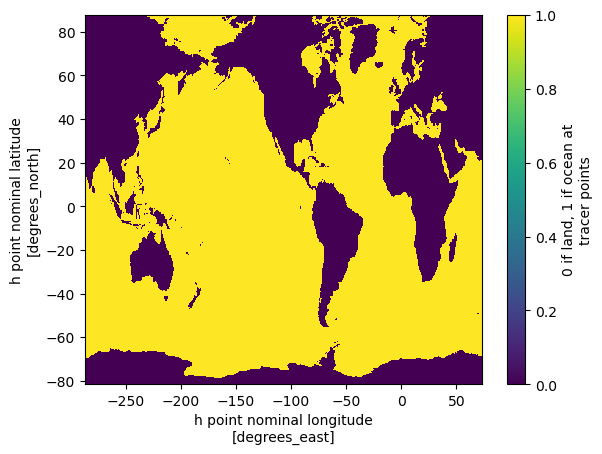

In [18]:
ds_grid.wet.plot()

In [19]:
ds_diff = xr.Dataset()

for var in variables2d:

    ds_diff[var] = ds_exp[var] - ds_ctrl[var]

In [20]:
ds_diff2 = xr.Dataset()

for var in variables3d:

    ds_diff2[var] = ds_exp2[var] - ds_ctrl2[var]

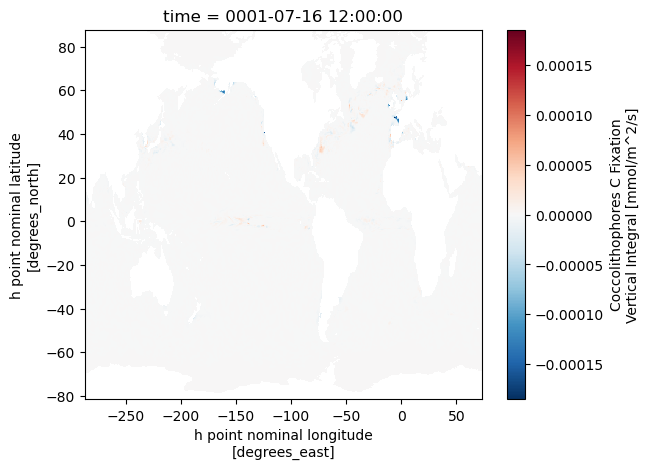

In [21]:
ds_diff.photoC_cocco_zint.isel(time=6).plot()

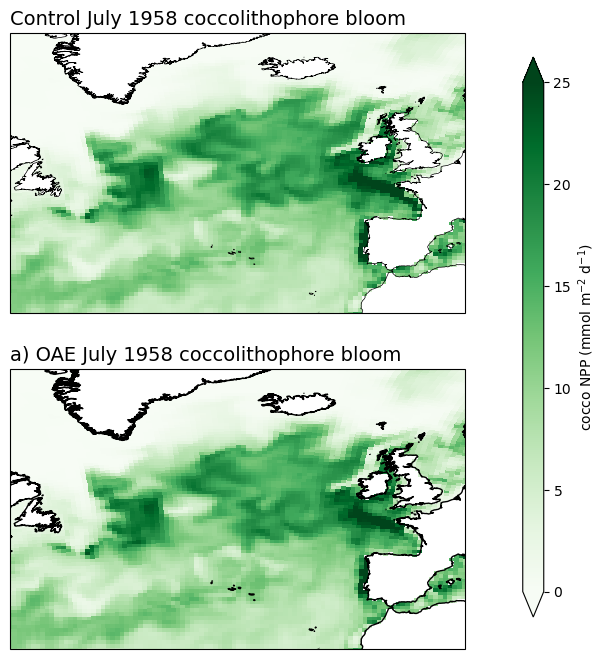

In [22]:
fig = plt.figure(figsize=(7,8))

############### 
ax = fig.add_subplot(2,1,1, projection=ccrs.PlateCarree())
ax.set_extent([-60, 5, 30, 70], ccrs.PlateCarree())

ax.set_title('Control July 1958 coccolithophore bloom', loc='left',fontsize=14)

field = ds_ctrl.photoC_cocco_zint.isel(time=6) * 86400 #mmol/m2/d

pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='Greens',
                   vmin=0,vmax=25)

ax.coastlines('10m',linewidth=0.5)

#cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='cocco NPP (mmol m$^{-2}$ d$^{-21}$)')
#############
ax = fig.add_subplot(2,1,2, projection=ccrs.PlateCarree())
ax.set_extent([-60, 5, 30, 70], ccrs.PlateCarree())
ax.set_title('a) OAE July 1958 coccolithophore bloom', loc='left',fontsize=14)

field = ds_exp.photoC_cocco_zint.isel(time=6) * 86400 #mmol/m2/d

pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='Greens',
                   vmin=0,vmax=25)

ax.coastlines('10m',linewidth=1)

############
cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
fig.colorbar(pc, cax=cbar_ax,extend='both',label='cocco NPP (mmol m$^{-2}$ d$^{-1}$)')

#fig.savefig('/glade/work/kristenk/figs/NAtl_cocco_bloom.png', bbox_inches='tight', dpi=300, format='png');

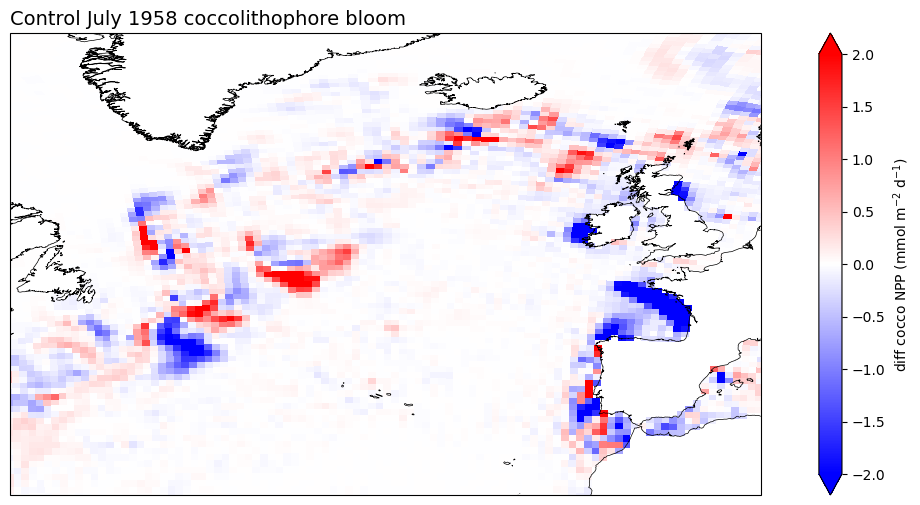

In [23]:
fig = plt.figure(figsize=(15,6))

############### 
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.set_extent([-60, 5, 30, 70], ccrs.PlateCarree())

ax.set_title('Control July 1958 coccolithophore bloom', loc='left', fontsize=14)

field = ds_diff.photoC_cocco_zint.isel(time=6) * 86400 #mmol/m2/d

pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='bwr',
                   vmin=-2,vmax=2)

ax.coastlines('10m',linewidth=0.5)

cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='diff cocco NPP (mmol m$^{-2}$ d$^{-1}$)')
#fig.savefig('/glade/work/kristenk/figs/NAtl_cocco_response.png', bbox_inches='tight', dpi=300, format='png');

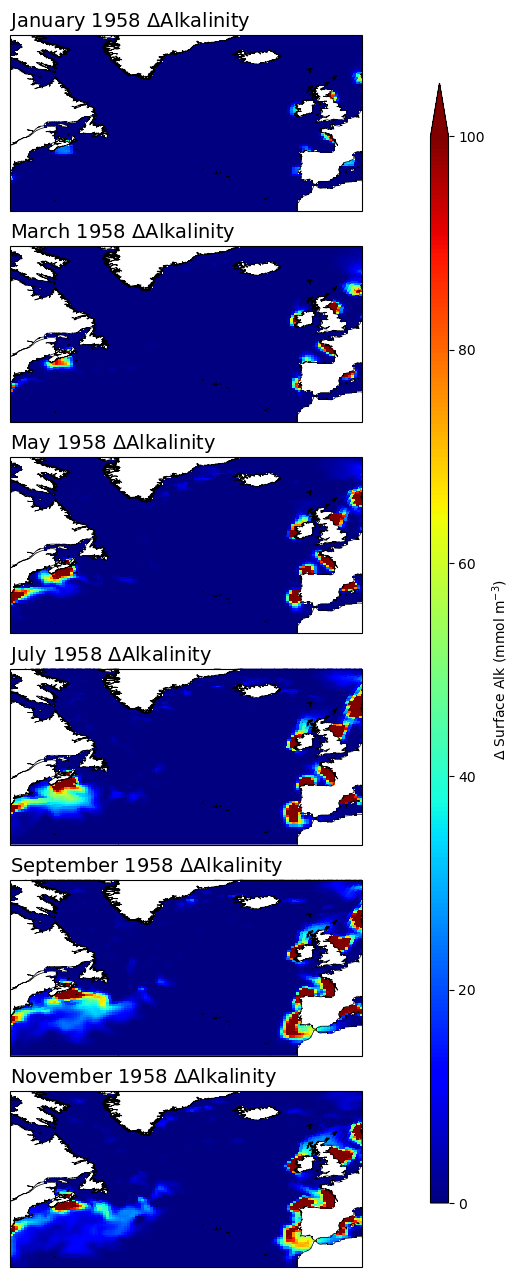

In [24]:
fig = plt.figure(figsize=(6,16))

extent=[-75, 5, 30, 70]

############### 
ax = fig.add_subplot(6,1,1, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('January 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=0)

pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)

ax.coastlines('10m',linewidth=0.5)

#cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='${\Delta}$ Surface Alk (mmol m$^{-3}$)')

ax = fig.add_subplot(6,1,2, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('March 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=2)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)


###########
ax = fig.add_subplot(6,1,3, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('May 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=4)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

###########
ax = fig.add_subplot(6,1,4, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('July 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=6)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)


###########
ax = fig.add_subplot(6,1,5, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('September 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=8)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

###########
ax = fig.add_subplot(6,1,6, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('November 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=10)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
fig.colorbar(pc, cax=cbar_ax,extend='max',label='${\Delta}$ Surface Alk (mmol m$^{-3}$)')



#fig.savefig('/glade/work/kristenk/figs/NAtl_extra_alk_fluxes.png', bbox_inches='tight', dpi=300, format='png');

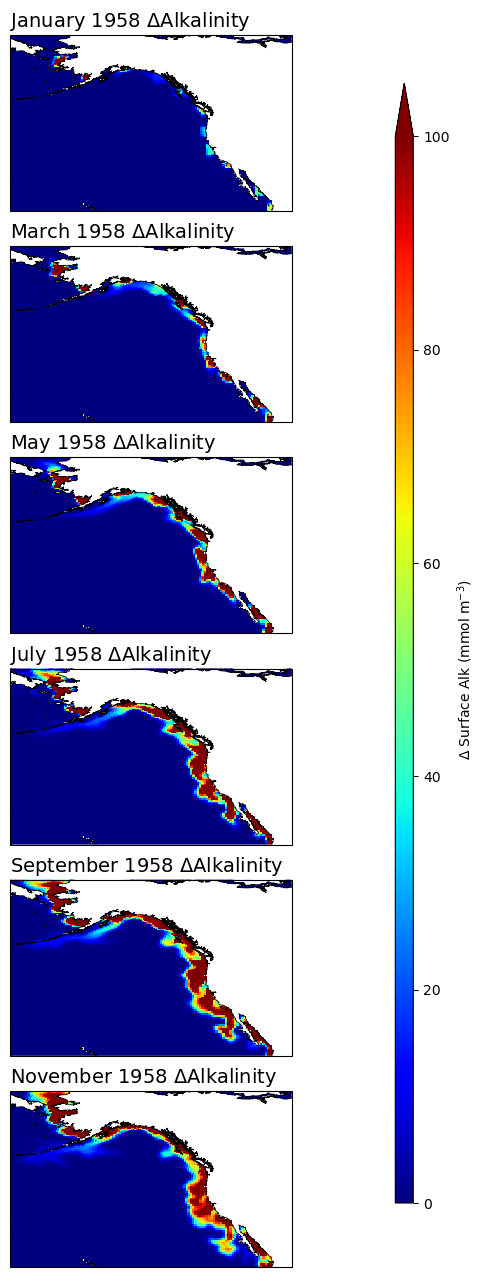

In [25]:
fig = plt.figure(figsize=(6,16))

extent=[-180, -100, 20, 70]

############### 
ax = fig.add_subplot(6,1,1, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('January 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=0)

pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)

ax.coastlines('10m',linewidth=0.5)

#cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='${\Delta}$ Surface Alk (mmol m$^{-3}$)')

ax = fig.add_subplot(6,1,2, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('March 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=2)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)


###########
ax = fig.add_subplot(6,1,3, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('May 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=4)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

###########
ax = fig.add_subplot(6,1,4, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('July 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=6)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)


###########
ax = fig.add_subplot(6,1,5, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('September 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=8)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

###########
ax = fig.add_subplot(6,1,6, projection=ccrs.PlateCarree())
ax.set_extent(extent, ccrs.PlateCarree())

ax.set_title('November 1958 ${\Delta}$Alkalinity', loc='left',fontsize=14)

field = ds_diff2.ALK.isel(time=10)
pc = ax.pcolormesh(lons,lats,field,
                    transform=ccrs.PlateCarree(),cmap='jet',
                   vmin=0,vmax=100)
ax.coastlines('10m',linewidth=0.5)

cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
fig.colorbar(pc, cax=cbar_ax,extend='max',label='${\Delta}$ Surface Alk (mmol m$^{-3}$)')



#fig.savefig('/glade/work/kristenk/figs/Pac_extra_alk_fluxes.png', bbox_inches='tight', dpi=300, format='png');

In [26]:
ds_diff.FG_CO2

<xarray.DataArray 'FG_CO2' (time: 60, yh: 480, xh: 540)> Size: 62MB
dask.array<sub, shape=(60, 480, 540), dtype=float32, chunksize=(1, 480, 540), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 4kB -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * yh       (yh) float64 4kB -81.56 -81.46 -81.36 -81.26 ... 87.65 87.71 87.74
  * time     (time) object 480B 0001-01-16 12:00:00 ... 0005-12-16 12:00:00
Attributes:
    units:          mmol/m^2/s
    long_name:      DIC Surface Gas Flux
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

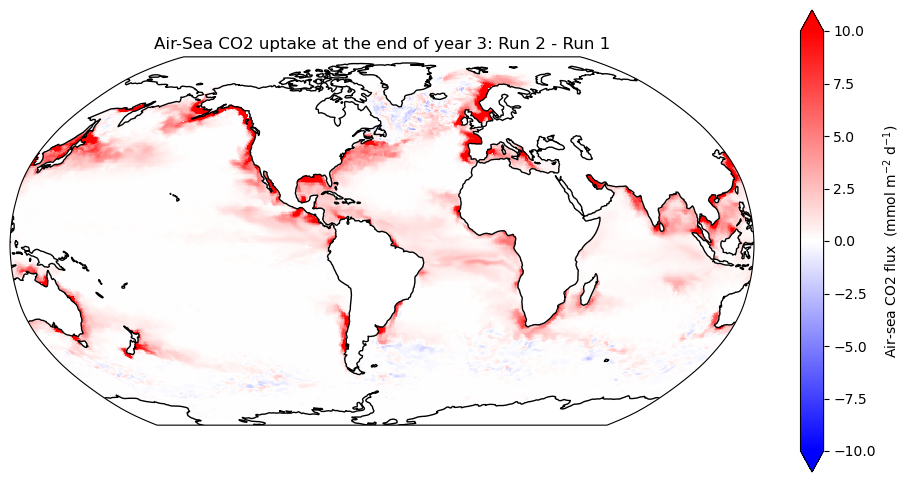

In [27]:
fig = plt.figure(figsize=(12,6))

ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=305.0))
ax.set_title('Air-Sea CO2 uptake at the end of year 3: Run 2 - Run 1', fontsize=12)
pc=ax.pcolormesh(lons, lats, ds_diff.FG_CO2.isel(time=35) * 86400, cmap='bwr',vmin=-10,vmax=10,transform=ccrs.PlateCarree())
ax.coastlines('110m',linewidth=1)
cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='Air-sea CO2 flux  (mmol m$^{-2}$ d$^{-1}$)')

### Global carbon cycle fluxes

In [28]:
ds_glb_ctrl = xr.Dataset()
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = [f'photoC_{phyto}_zint' for phyto in ['diat', 'sp', 'diaz', 'cocco', 'TOT']]
variables = variables + ['CaCO3_PROD_zint','POC_FLUX_100m','FG_CO2']

for v in variables:
    ds_glb_ctrl[v] = ((ds_ctrl[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
    ds_glb_ctrl[v].attrs = ds_ctrl[v].attrs

    ds_glb_ctrl[v] = ds_glb_ctrl[v] * mmols_to_PgCyr        
    ds_glb_ctrl[v].attrs['units'] = 'Pg C yr$^{-1}$'

ds_glb_ctrl_ann = ds_glb_ctrl.resample({'time':'A'}).mean(dim='time').compute()

In [29]:
ds_glb_exp = xr.Dataset()
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = [f'photoC_{phyto}_zint' for phyto in ['diat', 'sp', 'diaz', 'cocco', 'TOT']]
variables = variables + ['CaCO3_PROD_zint','POC_FLUX_100m','FG_CO2']

for v in variables:
    ds_glb_exp[v] = ((ds_exp[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
    ds_glb_exp[v].attrs = ds_exp[v].attrs

    ds_glb_exp[v] = ds_glb_exp[v] * mmols_to_PgCyr        
    ds_glb_exp[v].attrs['units'] = 'Pg C yr$^{-1}$'

ds_glb_exp_ann = ds_glb_exp.resample({'time':'A'}).mean(dim='time').compute()

In [33]:
ds_glb_exp.CaCO3_PROD_zint.values

array([0.23069194, 0.62319636, 1.15882   , 1.398469  , 1.452357  ,
       1.4118979 , 1.3840075 , 1.3876209 , 1.3486445 , 1.3413668 ,
       1.3858371 , 1.4441849 , 1.510422  , 1.5482595 , 1.5423795 ,
       1.4710261 , 1.4276004 , 1.3631065 , 1.3597542 , 1.3938864 ,
       1.397428  , 1.3769424 , 1.3989903 , 1.4107711 , 1.4682523 ,
       1.4943784 , 1.4790562 , 1.4317209 , 1.3881334 , 1.337965  ,
       1.3606958 , 1.3629801 , 1.3859242 , 1.3225625 , 1.3798637 ,
       1.3686348 , 1.415433  , 1.4574902 , 1.4311048 , 1.4068049 ,
       1.3797654 , 1.3395058 , 1.3162853 , 1.3153089 , 1.3005289 ,
       1.3117423 , 1.3451921 , 1.3526455 , 1.388758  , 1.3865345 ,
       1.3655835 , 1.3368112 , 1.3160006 , 1.3120762 , 1.3225732 ,
       1.3291497 , 1.3059237 , 1.2815111 , 1.3030934 , 1.3227086 ],
      dtype=float32)

In [34]:
ds_glb_ctrl.CaCO3_PROD_zint.values

array([0.2306885, 0.6232348, 1.1588935, 1.3987669, 1.4536978, 1.4129468,
       1.3843249, 1.389702 , 1.3494337, 1.341604 , 1.386708 , 1.4449611,
       1.512321 , 1.5497816, 1.5434401, 1.4696075, 1.428924 , 1.3646387,
       1.3602313, 1.3942218, 1.3979112, 1.375707 , 1.3990291, 1.4119818,
       1.4667324, 1.4932513, 1.4790224, 1.4303701, 1.3879147, 1.3369782,
       1.3595911, 1.3613088, 1.38437  , 1.3219074, 1.3798026, 1.3675822,
       1.414887 , 1.4539768, 1.4298332, 1.4069922, 1.3804096, 1.3400798,
       1.3182021, 1.3146212, 1.2995332, 1.3094481, 1.3445005, 1.3511491,
       1.3870946, 1.3857234, 1.365054 , 1.3369153, 1.3168055, 1.3117028,
       1.3217862, 1.3290392, 1.3033787, 1.280896 , 1.3022764, 1.3213731],
      dtype=float32)

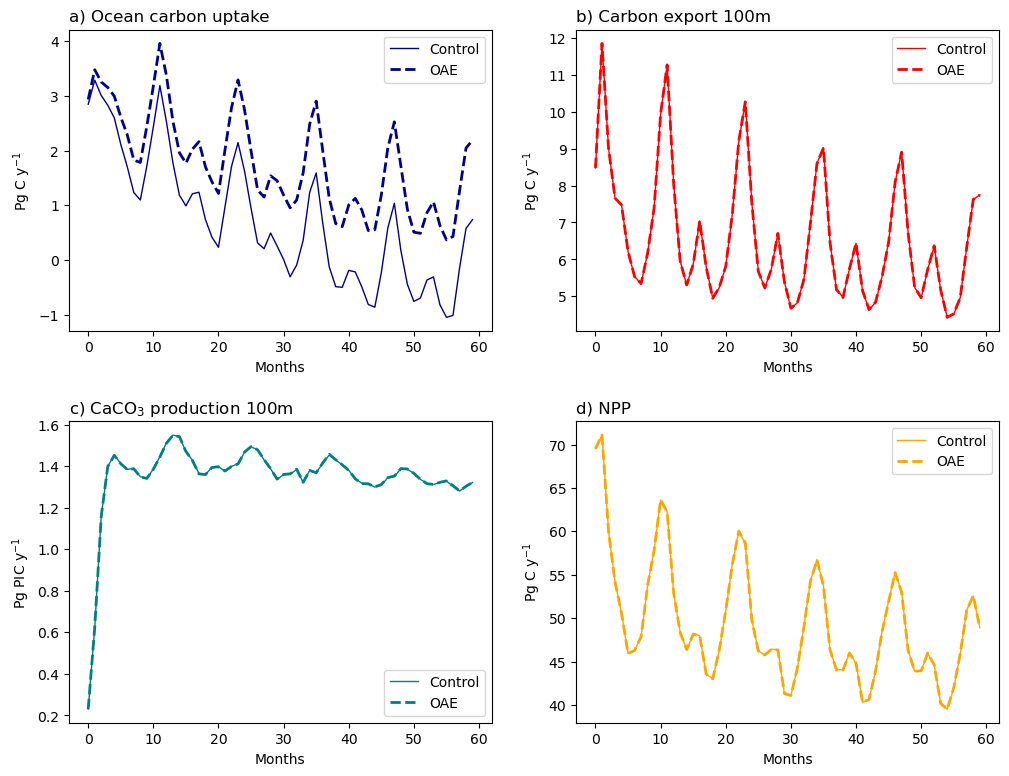

In [44]:
fig = plt.figure(figsize=(12,9))

#############################
ax = fig.add_subplot(2, 2, 1)
ax.set_title("a) Ocean carbon uptake", loc="left", fontsize=12)
   
ax.plot(ds_glb_ctrl['FG_CO2'],
           color='darkblue', zorder=2, linewidth=1, label='Control')
   
ax.plot(ds_glb_exp['FG_CO2'],
           color='darkblue', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 2)
ax.set_title("b) Carbon export 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_ctrl['POC_FLUX_100m'],
           color='red', zorder=2, linewidth=1, label='Control')
 
ax.plot(ds_glb_exp['POC_FLUX_100m'],
           color='red', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 3)
ax.set_title("c) CaCO$_3$ production 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_ctrl['CaCO3_PROD_zint'],
           color='teal', zorder=2, linewidth=1, label='Control')

ax.plot(ds_glb_exp['CaCO3_PROD_zint'],
           color='teal', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg PIC y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 4)
ax.set_title("d) NPP", loc="left", fontsize=12)


ax.plot(ds_glb_ctrl['photoC_TOT_zint'],
           color='orange', zorder=2, linewidth=1, label='Control')
    
ax.plot(ds_glb_exp['photoC_TOT_zint'],
           color='orange', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.legend()
ax.set_xlabel('Months') #, labelpad=-1)
ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)

fig.subplots_adjust(hspace=0.3)
#fig.savefig('/glade/work/kristenk/figs/Global_line_plots_OAEvControl.png', bbox_inches='tight', dpi=300, format='png');

### Plot annual means

In [38]:
ds_glb_ctrl_ann['time'] = np.arange(1,len(ds_glb_ctrl_ann.time)+1,1)
ds_glb_exp_ann['time'] = np.arange(1,len(ds_glb_exp_ann.time)+1,1)

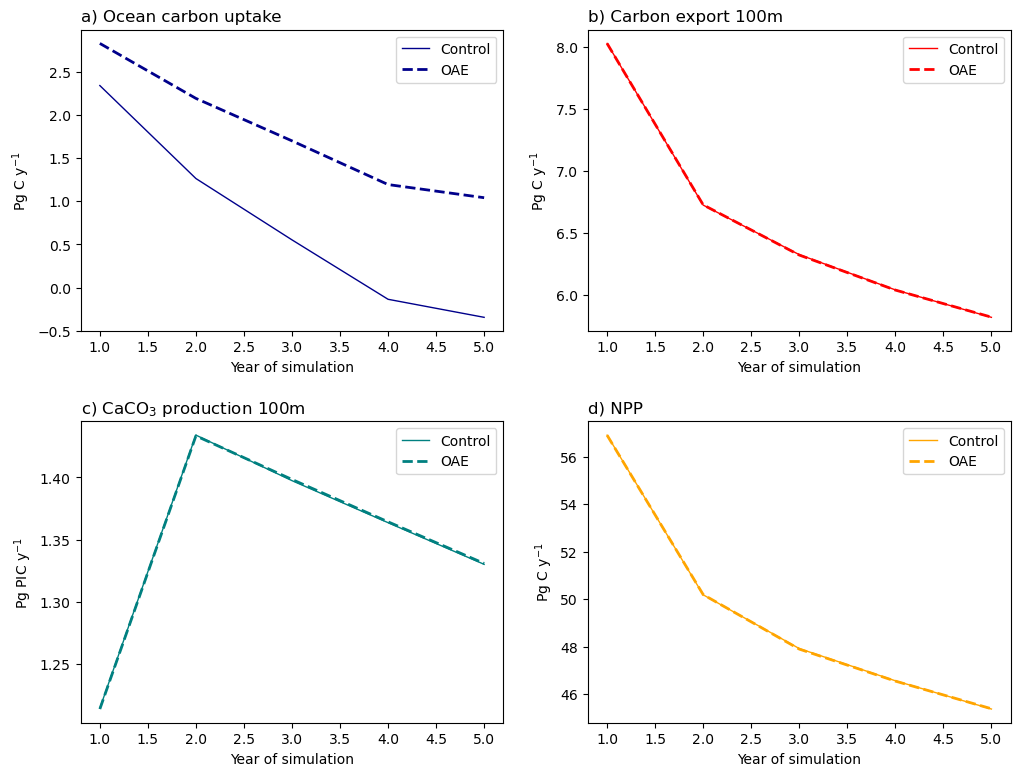

In [40]:
fig = plt.figure(figsize=(12,9))

#############################
ax = fig.add_subplot(2, 2, 1)
ax.set_title("a) Ocean carbon uptake", loc="left", fontsize=12)
   
ax.plot(ds_glb_ctrl_ann.time, ds_glb_ctrl_ann['FG_CO2'],
           color='darkblue', zorder=2, linewidth=1, label='Control')
   
ax.plot(ds_glb_exp_ann.time, ds_glb_exp_ann['FG_CO2'],
           color='darkblue', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Year of simulation')
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 2)
ax.set_title("b) Carbon export 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_ctrl_ann.time, ds_glb_ctrl_ann['POC_FLUX_100m'],
           color='red', zorder=2, linewidth=1, label='Control')
 
ax.plot(ds_glb_exp_ann.time, ds_glb_exp_ann['POC_FLUX_100m'],
           color='red', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Year of simulation')
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 3)
ax.set_title("c) CaCO$_3$ production 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_ctrl_ann.time, ds_glb_ctrl_ann['CaCO3_PROD_zint'],
           color='teal', zorder=2, linewidth=1, label='Control')

ax.plot(ds_glb_exp_ann.time, ds_glb_exp_ann['CaCO3_PROD_zint'],
           color='teal', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.set_ylabel('Pg PIC y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Year of simulation')
ax.legend()

#############################
ax = fig.add_subplot(2, 2, 4)
ax.set_title("d) NPP", loc="left", fontsize=12)


ax.plot(ds_glb_ctrl_ann.time, ds_glb_ctrl_ann['photoC_TOT_zint'],
           color='orange', zorder=2, linewidth=1, label='Control')
    
ax.plot(ds_glb_exp_ann.time, ds_glb_exp_ann['photoC_TOT_zint'],
           color='orange', zorder=2, linewidth=2,linestyle='--',label='OAE')

ax.legend()
ax.set_xlabel('Year of simulation')
ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)

fig.subplots_adjust(hspace=0.3)


#fig.savefig('/glade/work/kristenk/figs/Global_line_plots_OAEvControl.png', bbox_inches='tight', dpi=300, format='png');

### Plot anomalies

In [41]:
ds_glb_anom = ds_glb_exp - ds_glb_ctrl

In [42]:
ds_glb_anom_ann = ds_glb_exp_ann - ds_glb_ctrl_ann

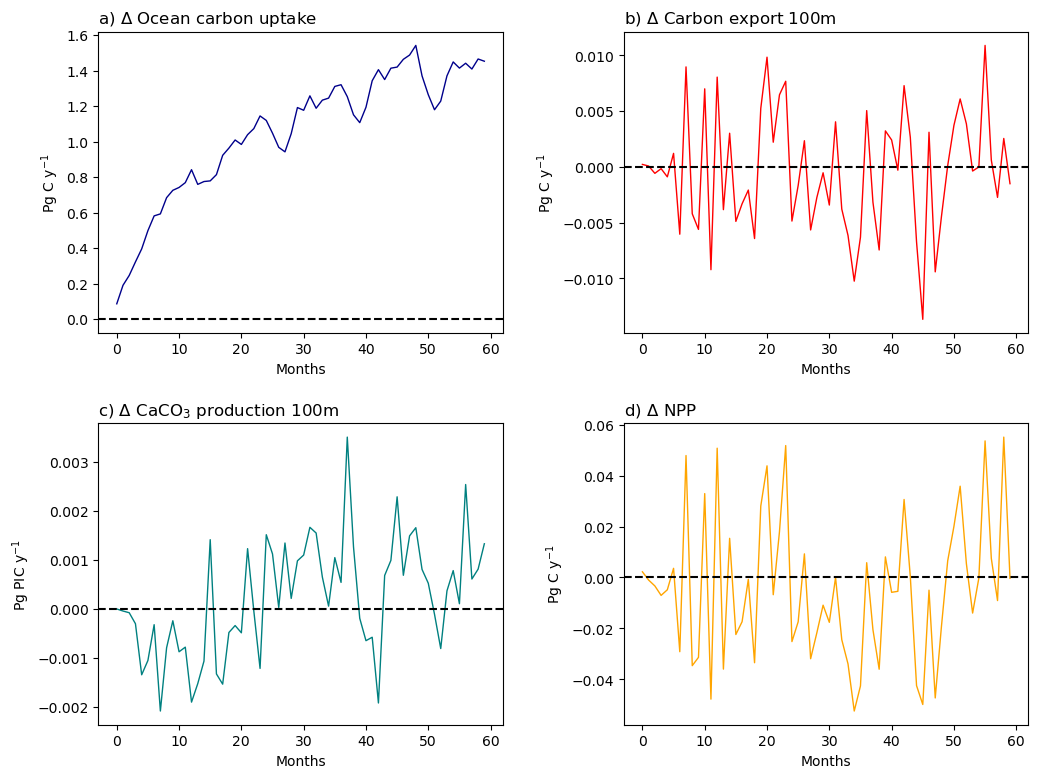

In [51]:
fig = plt.figure(figsize=(12,9))

#############################
ax = fig.add_subplot(2, 2, 1)
ax.set_title("a) ${\Delta}$ Ocean carbon uptake", loc="left", fontsize=12)
   
ax.plot(ds_glb_anom['FG_CO2'],
           color='darkblue', zorder=2, linewidth=1)
ax.axhline(0,linestyle='--',color='black')
ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)

#############################
ax = fig.add_subplot(2, 2, 2)
ax.set_title("b) ${\Delta}$ Carbon export 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_anom['POC_FLUX_100m'],
           color='red', zorder=2, linewidth=1)
ax.axhline(0,linestyle='--',color='black')
ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)

#############################
ax = fig.add_subplot(2, 2, 3)
ax.set_title("c) ${\Delta}$ CaCO$_3$ production 100m", loc="left", fontsize=12)
    
ax.plot(ds_glb_anom['CaCO3_PROD_zint'],
           color='teal', zorder=2, linewidth=1)
ax.axhline(0,linestyle='--',color='black')
ax.set_ylabel('Pg PIC y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)

#############################
ax = fig.add_subplot(2, 2, 4)
ax.set_title("d) ${\Delta}$ NPP", loc="left", fontsize=12)

ax.plot(ds_glb_anom['photoC_TOT_zint'],
           color='orange', zorder=2, linewidth=1)
ax.axhline(0,linestyle='--',color='black')
ax.set_ylabel('Pg C y$^{-1}$') #, labelpad=-1)
ax.set_xlabel('Months') #, labelpad=-1)


fig.subplots_adjust(hspace=0.3, wspace=0.3)
#fig.savefig('/glade/work/kristenk/figs/Global_line_plots_OAEvControl.png', bbox_inches='tight', dpi=300, format='png');